## **Problem:**

An agricultural management agency needs to conduct a rapid assessment of land cover status in a vulnerable region following an extreme weather event (e.g., drought or flooding). They lack up-to-date baseline data for the area but have access to thousands of high-resolution satellite images of the region.

The goal is to use cluster analysis to group these images into categories (clusters) representing different land cover types (e.g., healthy cropland, dense forest, bare soil, flooded area). It is hypothesized that clusters representing "bare soil," "industrial area," or "stagnant water" are indicators of damaged or at-risk agroecological zones.

https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

In [ ]:
!pip install rich

In [ ]:
!pip install --upgrade keras

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
from keras import layers, Model
import tensorflow as tf

print(f"Versión de Keras: {keras.__version__}")

Versión de Keras: 3.14.0


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import functools
from PIL import Image
from rich.console import Console
from IPython import display as ipythondisplay

console = Console()

## **Donwload Data**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

console.print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.


Path to dataset files: /kaggle/input/eurosat-dataset

In [ ]:
!ls {path}/EuroSAT/

AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


In [ ]:
from torch import e
from genericpath import isdir
import os

eurosat_classes = {
    "AnnualCrop": 0,
    'Forest': 1,
    'HerbaceousVegetation': 2,
    'Highway': 3,
    'Industrial': 4,
    'Pasture': 5,
    'PermanentCrop': 6,
    'Residential': 7,
    'River': 8,
    'SeaLake': 9,
}

all_images = []
all_images_y = []

for directory in os.listdir(path + "/EuroSAT/"):
  if os.path.isdir(path + "/EuroSAT/" + directory):
    y = -1
    console.print(f"Directory: {directory}")
    match directory:
      case "AnnualCrop":
        y = eurosat_classes["AnnualCrop"]
      case "Forest":
        y = eurosat_classes["Forest"]
      case "HerbaceousVegetation":
        y = eurosat_classes["HerbaceousVegetation"]
      case "Highway":
        y = eurosat_classes["Highway"]
      case "Industrial":
        y = eurosat_classes["Industrial"]
      case "Pasture":
        y = eurosat_classes["Pasture"]
      case "PermanentCrop":
        y = eurosat_classes["PermanentCrop"]
      case "Residential":
        y = eurosat_classes["Residential"]
      case "River":
        y = eurosat_classes["River"]
      case "SeaLake":
        y = eurosat_classes["SeaLake"]
    console.print(f"y: {y}")
    directory_images = []

    for file in os.listdir(path + "/EuroSAT/" + directory):
      all_images.append(path + "/EuroSAT/" + directory + "/" + file)
      directory_images.append(path + "/EuroSAT/" + directory + "/" + file)

    console.print(f"Number of images in directory: {len(directory_images)}")
    all_images_y.append({"images":directory_images, "y": y})

console.print(f"Total Number of images: {len(all_images)}")

Directory: SeaLake

y: 9

Number of images in directory: 3000

Directory: Highway

y: 3

...

Number of images in directory: 3000

Directory: HerbaceousVegetation

y: 2

Number of images in directory: 3000

Total Number of images: 27000

Imagen 1 (Industrial_1541.jpg): Real Size = (64, 64)
Imagen 2 (River_2101.jpg): Real Size = (64, 64)
Imagen 3 (PermanentCrop_259.jpg): Real Size = (64, 64)


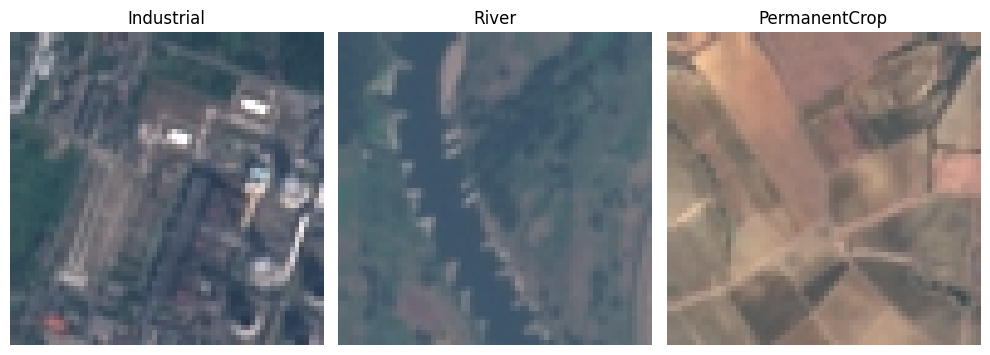

In [ ]:
sample_images = random.sample(all_images, 3)

plt.figure(figsize=(10, 5))
for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    print(f"Imagen {i+1} ({img_path.split('/')[-1]}): Real Size = {img.size}")
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.split('/')[-2])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
file_paths = []
labels = []

for entry in all_images_y:
    for img_path in entry["images"]:
        file_paths.append(img_path)
        labels.append(entry["y"])

file_paths = tf.constant(file_paths)
labels = tf.constant(labels)

In [ ]:
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(img, channels=3)
    # normalization
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [64, 64])

    return img, label

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
dataset = dataset.shuffle(buffer_size=len(file_paths))
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
BATCH_SIZE = 32
TRAIN_SIZE = 21600

dataset_train = dataset.take(TRAIN_SIZE)
dataset_train = dataset_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

dataset_test = dataset.skip(TRAIN_SIZE)
dataset_test = dataset_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

dataset_train = dataset_train.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

## **Vision Transformers (ViT) Classification**

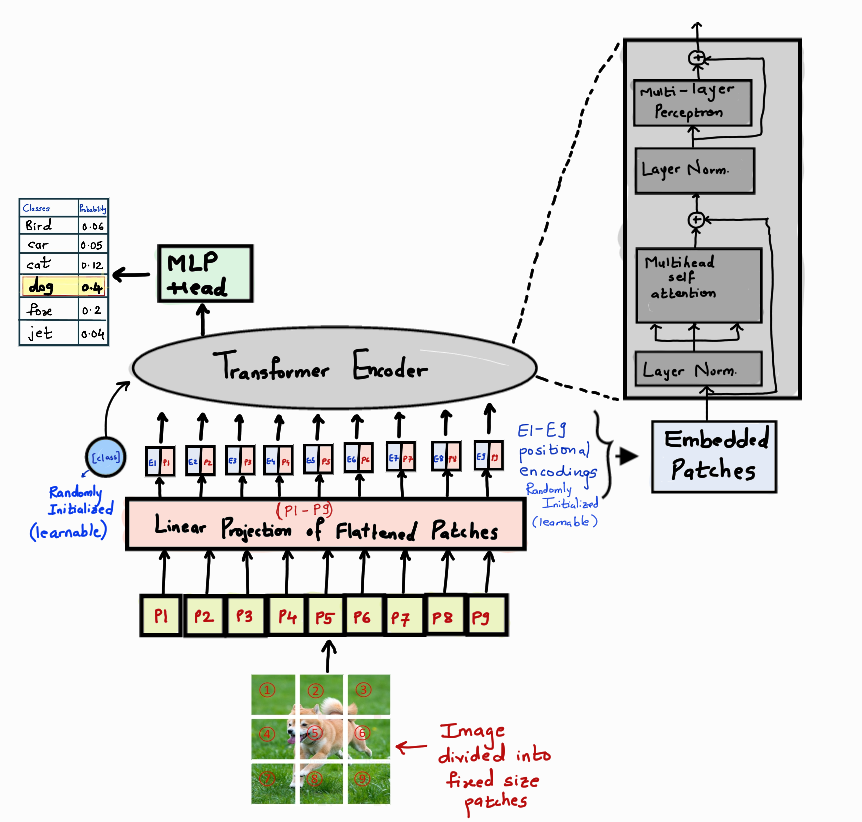


https://medium.com/machine-intelligence-and-deep-learning-lab/vit-vision-transformer-cc56c8071a20

### **Patch Embedding**

Patch Embedding is the process of dividing an input image into fixed-size, non-overlapping patches (e.g., $16 \times 16$), flattening them into vectors, and projecting them into a higher-dimensional embedding space using a linear transformation. This effectively treats each spatial region of the image as a unique "visual token," similar to how words are treated in NLP, enabling the Transformer to model global dependencies across the entire image via self-attention

### **CLS token**

In the context of Vision Transformers (ViT), the [CLS] token is a specially initialized, learnable vector prepended to the sequence of image patch embeddings.

Its primary purpose is to serve as a global representation of the entire image for classification tasks. Since the self-attention mechanism allows every token in the sequence to interact with every other token, the [CLS] token "attends" to all image patches throughout the Transformer layers, effectively aggregating the most relevant features needed for a final prediction.

Using a dedicated token, rather than averaging all patch embeddings (Global Average Pooling), follows the architectural design of BERT in Natural Language Processing, providing a clean bottleneck where the model can distill spatial information into a single class-level descriptor.

Reference:

- Dosovitskiy, A., et al. (2020). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. International Conference on Learning Representations (ICLR).

In [ ]:
class ViTPatchEmbedding(layers.Layer):
    """
    Implements the Patch Embedding layer for ViT.
    Converts an input image into a sequence of linear projections (patches)
    and adds a learnable [CLS] token and positional embeddings.
    """
    def __init__(self, patch_size, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        # Convolutional projection to extract patches and project to embed_dim
        # Using kernel_size and strides equal to patch_size ensures non-overlapping patches
        self.projection = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )
        # Reshape the 2D feature map into a 1D sequence of patches
        self.flatten = layers.Reshape(target_shape=(num_patches, embed_dim))

        # Learnable [CLS] token: initialized as a weight of shape (1, 1, embed_dim)
        self.cls_token = self.add_weight(
            name="cls_token", shape=(1, 1, embed_dim),
            initializer="random_normal", trainable=True
        )

        # Learnable Positional Embeddings: shape (1, num_patches + 1, embed_dim)
        # The '+ 1' accounts for the added [CLS] token
        self.pos_embedding = self.add_weight(
            name="pos_embedding", shape=(1, num_patches + 1, embed_dim),
            initializer="random_normal", trainable=True
        )

    def call(self, images):
        batch_size = tf.shape(images)[0]

        # Step 1: Project image to patches -> Shape: (batch, grid_h, grid_w, embed_dim)
        x = self.projection(images)

        # Step 2: Flatten to sequence -> Shape: (batch, num_patches, embed_dim)
        x = self.flatten(x)

        # Step 3: Prepend the [CLS] token to the sequence
        # Broadcast the single cls_token to match the current batch size
        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, tf.shape(x)[-1]])

        # Concatenate on the sequence dimension (axis 1)
        x = tf.concat([cls_tokens, x], axis=1) # Shape: (batch, num_patches + 1, embed_dim)

        # Step 4: Add positional information to each token in the sequence
        return x + self.pos_embedding

In [ ]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.4, **kwargs):
        super().__init__(**kwargs)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads
        )
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        # 1. Multi-Head Attention
        x = self.layernorm1(inputs)
        attn_output = self.mha(
            query=x,
            value=x,
            key=x,
            training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = inputs + attn_output

        # 2. Feed Forward
        x = self.layernorm2(out1)
        ffn_output = self.ffn(x)
        ffn_output = self.dropout2(ffn_output, training=training)
        return out1 + ffn_output

    def compute_output_shape(self, input_shape):
      return input_shape

In [ ]:
class VisionTransformer(tf.keras.Model):
    """
    The complete ViT architecture for Image Classification.
    """
    def __init__(self, patch_size, num_patches, embed_dim, num_heads, ff_dim, num_layers, num_classes):
        super().__init__()
        # Initialize the embedding block (Projections + Tokens + Positions)
        self.embedding_block = ViTPatchEmbedding(patch_size, num_patches, embed_dim)

        # Stack multiple Transformer Encoder layers
        self.encoder_layers = [
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim)
            for _ in range(num_layers)
        ]

        # Classification Head: predicting logits for the target classes
        self.mlp_head = layers.Dense(num_classes)

    def call(self, inputs, training=False):
        # Step 1: Input images to patch sequence
        x = self.embedding_block(inputs)

        # Step 2: Forward through all Encoder blocks
        for layer in self.encoder_layers:
            x = layer(x, training=training)

        # Step 3: Extract the [CLS] token representation (index 0 of the sequence)
        # This token has aggregated information from all patches via self-attention
        cls_output = x[:, 0, :]

        # Step 4: Final prediction
        return self.mlp_head(cls_output)

In [ ]:
patch_size = 8 # 8x8 Pixels
img_size = 64
num_patches = (img_size // patch_size) ** 2 # 64 parches

embed_dim = 64
num_heads = 4
ff_dim = 128
num_encoder_blocks = 2
num_classes = 10

model_vit = VisionTransformer(
    patch_size=patch_size,
    num_patches=num_patches,
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_layers=num_encoder_blocks,
    num_classes=num_classes
)

In [ ]:
model_vit.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,     # Reduce LR
    patience=10,
    min_lr=1e-6,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

In [ ]:
EPOCHS = 100

history_vit = model_vit.fit(
    dataset_train,
    validation_data=dataset_test,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        lr_reducer
    ]
)

Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 67s 63ms/step - accuracy: 0.3842 - loss: 1.6842 - val_accuracy: 0.5791 - val_loss: 1.1879 - learning_rate: 0.0010
Epoch 2/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5446 - loss: 1.2458 - val_accuracy: 0.5191 - val_loss: 1.4274 - learning_rate: 0.0010
Epoch 3/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6168 - loss: 1.0485 - val_accuracy: 0.6256 - val_loss: 1.1253 - learning_rate: 0.0010
Epoch 4/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6626 - loss: 0.9276 - val_accuracy: 0.6900 - val_loss: 0.8476 - learning_rate: 0.0010
Epoch 5/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6919 - loss: 0.8540 - val_accuracy: 0.6889 - val_loss: 0.9237 - learning_rate: 0.0010
Epoch 6/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7130 - loss: 0.7994 - val_accuracy: 0.7063 - val_loss: 0.8888 - learning_rate: 0.0010
Epoch 7/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7323 - loss:

## **Predict**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict_and_plot(model, dataset, class_names, num_images=5):
    images, labels = next(iter(dataset.take(1)))

    predictions = model.predict(images)

    probabilities = tf.nn.softmax(predictions).numpy()

    plt.figure(figsize=(15, num_images * 3))

    for i in range(num_images):
        pred_label = np.argmax(probabilities[i])
        true_label = labels[i].numpy()
        confidence = probabilities[i][pred_label] * 100

        plt.subplot(num_images, 1, i + 1)
        plt.imshow(images[i])
        color = "green" if pred_label == true_label else "red"

        plt.title(
            f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} ({confidence:.2f}%)",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

class_names = list(eurosat_classes.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


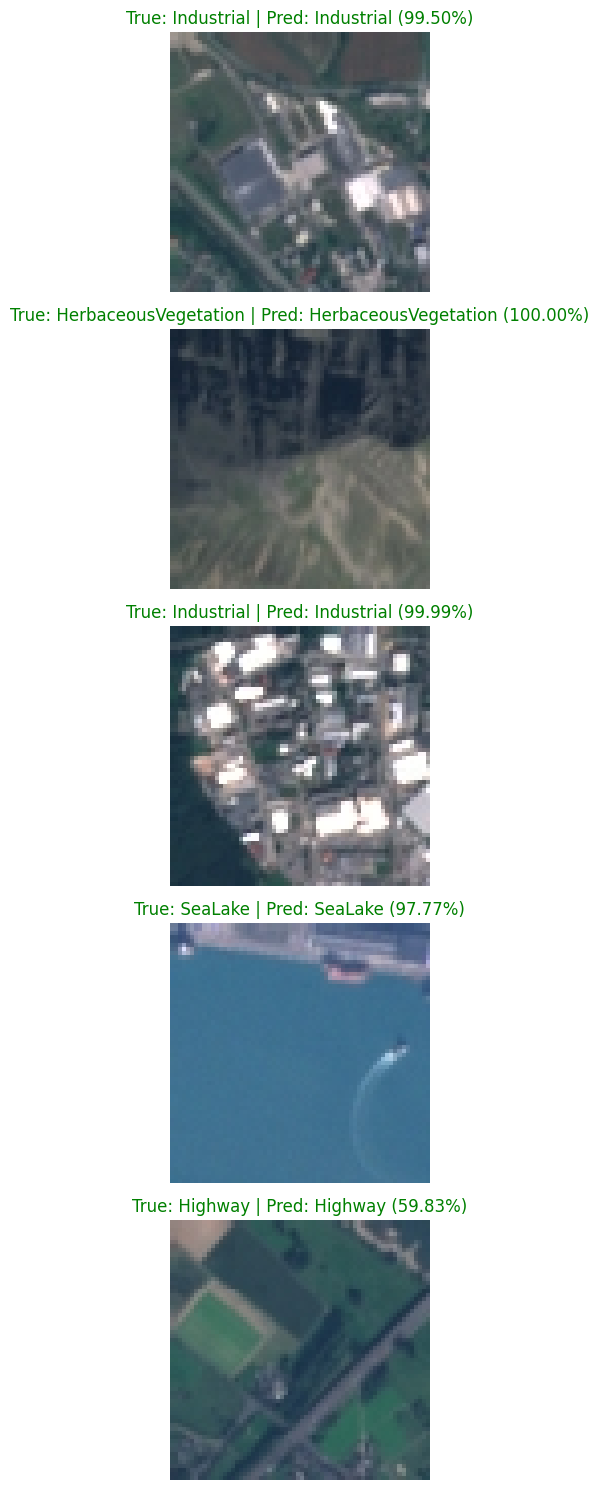

In [ ]:
predict_and_plot(model_vit, dataset_test, class_names, num_images=5)

## **Validation and Metrics**

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in dataset_test:
    preds = model_vit.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

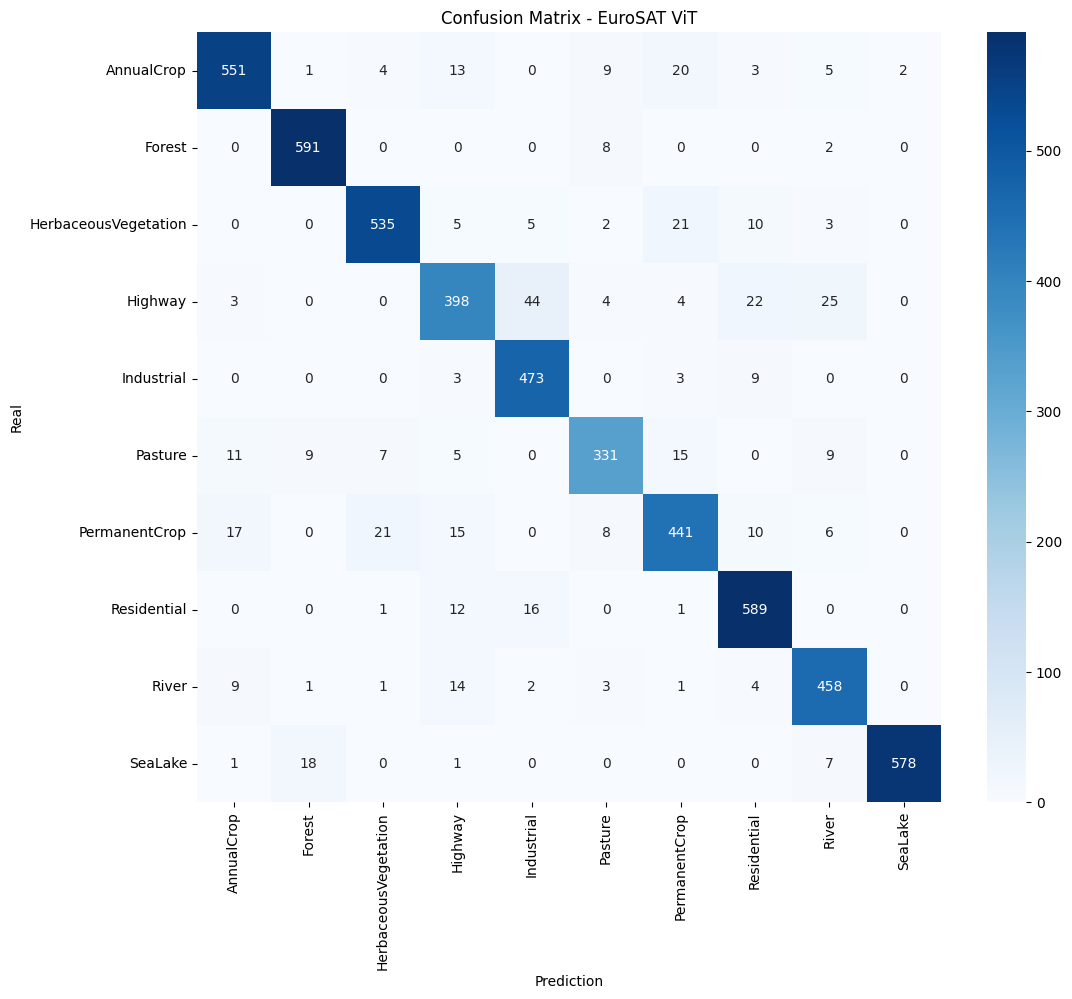

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prediction')
    plt.ylabel('Real')
    plt.title('Confusion Matrix - EuroSAT ViT')
    plt.show()

plot_confusion_matrix(y_true, y_pred, list(eurosat_classes.keys()))

In [ ]:
console.print(classification_report(y_true, y_pred, target_names=list(eurosat_classes.keys())))

precision    recall  f1-score   support

          AnnualCrop       0.93      0.91      0.92       608
              Forest       0.95      0.98      0.97       601
HerbaceousVegetation       0.94      0.92      0.93       581
             Highway       0.85      0.80      0.82       500
          Industrial       0.88      0.97      0.92       488
             Pasture       0.91      0.86      0.88       387
       PermanentCrop       0.87      0.85      0.86       518
         Residential       0.91      0.95      0.93       619
               River       0.89      0.93      0.91       493
             SeaLake       1.00      0.96      0.98       605

            accuracy                           0.92      5400
           macro avg       0.91      0.91      0.91      5400
        weighted avg       0.92      0.92      0.92      5400